To run the notebook, make sure the ERA5_SM_daily_1999_2021_0_5m.nc dataset is added to the folder. Otherwise, you should be able to run each cell as need be given you have the dependancies installed.

In [ ]:
import xarray as xr
import pandas as pd

ds = xr.open_dataset('ERA5_SM_daily_1999_2021_0_5m.nc')
print(ds)

<xarray.Dataset> Size: 39MB
Dimensions:  (time: 8401, lat: 25, lon: 46)
Coordinates:
  * lat      (lat) float32 100B 25.92 26.86 27.8 28.74 ... 46.65 47.59 48.53
  * lon      (lon) float32 184B 236.2 237.5 238.8 240.0 ... 290.0 291.2 292.5
Dimensions without coordinates: time
Data variables:
    swvRZ    (time, lat, lon) float32 39MB ...


In [ ]:
start_date = '1999-01-01'
num_days = ds.time.size
dates = pd.date_range(start=start_date, periods=num_days, freq='D')

# Assign the new date range to the 'time' coordinate
ds['time'] = dates

ds_mondays = ds.sel(time=ds['time'].dt.dayofweek == 0)
print(f"Shape of ds_mondays (swvRZ variable): {ds_mondays['swvRZ'].shape}")

Shape of ds_mondays (swvRZ variable): (1200, 25, 46)


In [ ]:
import numpy as np
import pandas as pd

df_model = soil_moisture_at_location.to_dataframe(name='soil_moisture')

print("Initial df_model head:")
print(df_model.head())


# Create lagged features for soil moisture
for i in range(1, 6):
    df_model[f'SM_lag{i}'] = df_model['soil_moisture'].shift(i)

# Extract time-based features
df_model['year'] = df_model.index.year
df_model['month'] = df_model.index.month
df_model['dayofyear'] = df_model.index.dayofyear

# Remove any rows from df_model that contain NaN values
df_model.dropna(inplace=True)

print("df_model head after adding features and dropping NaNs:")
print(df_model.head())
print("df_model info after adding features and dropping NaNs:")
df_model.info()

Initial df_model head:
                  lat    lon  soil_moisture
time                                       
1999-01-04  40.994766  275.0       0.165408
1999-01-11  40.994766  275.0       0.160931
1999-01-18  40.994766  275.0       0.179489
1999-01-25  40.994766  275.0       0.201175
1999-02-01  40.994766  275.0       0.191145
df_model head after adding features and dropping NaNs:
                  lat    lon  soil_moisture   SM_lag1   SM_lag2   SM_lag3  \
time                                                                        
1999-02-08  40.994766  275.0       0.196558  0.191145  0.201175  0.179489   
1999-02-15  40.994766  275.0       0.194049  0.196558  0.191145  0.201175   
1999-02-22  40.994766  275.0       0.187545  0.194049  0.196558  0.191145   
1999-03-01  40.994766  275.0       0.197638  0.187545  0.194049  0.196558   
1999-03-08  40.994766  275.0       0.198738  0.197638  0.187545  0.194049   

             SM_lag4   SM_lag5  year  month  dayofyear  
time             

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

def create_sequences(data, look_back, horizon):
    data = data.values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(data)

    X, y = [], []
    for i in range(len(scaled_data) - look_back - horizon + 1):
        X.append(scaled_data[i:(i + look_back), 0])
        y.append(scaled_data[(i + look_back):(i + look_back + horizon), 0])

    X = np.array(X)
    y = np.array(y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    return X, y, scaler

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

def build_lstm_model(input_shape, output_horizon):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, activation='tanh', return_sequences=True, name='lstm'),
        Dropout(0.1, name='dropout'),
        LSTM(32, activation='tanh', name='lstm_1'),
        Dense(output_horizon, name='dense')
    ])

    # Using explicit Adam optimizer
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model


Found 912 locations with data.


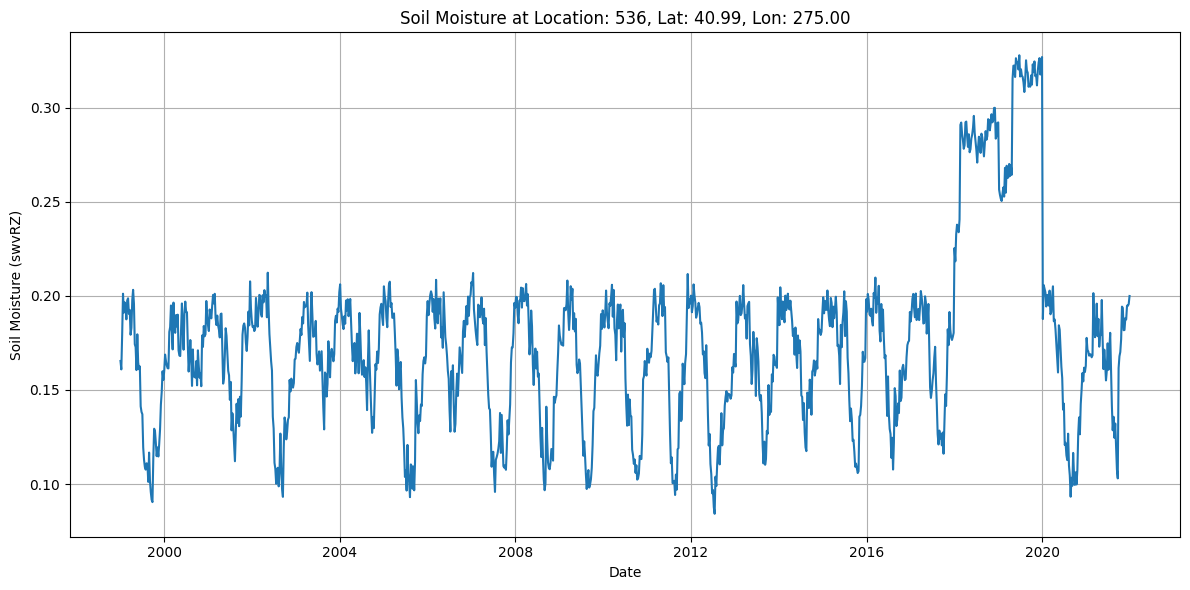

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Find non null locations (there should be 912)
valid_mask = ~ds_mondays['swvRZ'].isel(time=0).isnull()
lat_indices, lon_indices = np.where(valid_mask.values)

all_locations = []
for lat_idx, lon_idx in zip(lat_indices, lon_indices):
    lat_val = ds_mondays.lat.values[lat_idx]
    lon_val = ds_mondays.lon.values[lon_idx]
    all_locations.append((float(lat_val), float(lon_val)))

print(f"Found {len(all_locations)} locations with data.")

# Chosing a random loaction to help visualize what the soil data looks like
loc = random.randint(0, len(all_locations)-1)

display_lat = all_locations[loc][0]
display_lon = all_locations[loc][1]

soil_moisture_at_location = ds_mondays['swvRZ'].sel(lat=display_lat, lon=display_lon, method='nearest')

plt.figure(figsize=(12, 6))
soil_moisture_at_location.plot()

plt.title(f'Soil Moisture at Location: {loc}, Lat: {display_lat:.2f}, Lon: {display_lon:.2f}')

plt.xlabel('Date')
plt.ylabel('Soil Moisture (swvRZ)')

plt.grid(True)
plt.tight_layout()
plt.show()

For testing, if you want to run it only on a select few locations, uncomment the lines in the below cell. Otherwise, it will start to run for all 912 locations.

In [ ]:
import h5py
import numpy as np
import os

limit = 4
look_back_window = 40
forecast_horizon = 6

# count = 0
for i, (lat_val, lon_val) in enumerate(all_locations):
    sm_series = ds_mondays['swvRZ'].sel(lat=lat_val, lon=lon_val, method='nearest').to_series()
    X, y, scaler = create_sequences(sm_series, look_back=look_back_window, horizon=forecast_horizon)

    model = build_lstm_model((X.shape[1], X.shape[2]), forecast_horizon)

    model.fit(X, y, epochs=25, batch_size=32, verbose=0)

    model.save(f'lead_{look_back_window}/model_{i}.h5')

    # count += 1
    # if count >= limit:
    #     break

## File Structure

Here is the structure of the h5 files, so that future groups can work with the format. Instead of having one large h5 with all those rows (300 of which were redundant) each location's model will have its own file. If the dead spots are still occuring on the map this should allow you to retrain specific models.

In [ ]:
import h5py

def inspect_h5_hierarchy(name, obj):
    indent = name.count('/') * '  '
    print(f"{indent}{name}")

with h5py.File(f'lead_{look_back_window}/model_0.h5', 'r') as f:
    print("--- HDF5 File Structure ---")
    f.visititems(inspect_h5_hierarchy)

    # Specific check for requested groups
    if 'model_weights' in f and 'optimizer_weights' in f:
        print("\nLayers in model_weights:")
        for layer in f['model_weights'].keys():
            print(f" - {layer}")

        print("\nOptimizer attributes:")
        for opt_attr in f['optimizer_weights'].keys():
            print(f" - {opt_attr}")
    else:
        print("\nWarning: The expected group structure was not found.")

--- HDF5 File Structure ---
model_weights
  model_weights/dense
    model_weights/dense/sequential_158
      model_weights/dense/sequential_158/dense
        model_weights/dense/sequential_158/dense/bias
        model_weights/dense/sequential_158/dense/kernel
  model_weights/dropout
  model_weights/lstm
    model_weights/lstm/sequential_158
      model_weights/lstm/sequential_158/lstm
        model_weights/lstm/sequential_158/lstm/lstm_cell
          model_weights/lstm/sequential_158/lstm/lstm_cell/bias
          model_weights/lstm/sequential_158/lstm/lstm_cell/kernel
          model_weights/lstm/sequential_158/lstm/lstm_cell/recurrent_kernel
  model_weights/lstm_1
    model_weights/lstm_1/sequential_158
      model_weights/lstm_1/sequential_158/lstm_1
        model_weights/lstm_1/sequential_158/lstm_1/lstm_cell
          model_weights/lstm_1/sequential_158/lstm_1/lstm_cell/bias
          model_weights/lstm_1/sequential_158/lstm_1/lstm_cell/kernel
          model_weights/lstm_1/sequent

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import load_model
import numpy as np
import pandas as pd

def evaluate_h5_model(location_idx):
    # Load the locations model
    model_path = f'lead_{look_back_window}/model_{location_idx}.h5'
    model = load_model(model_path)

    lat_val, lon_val = all_locations[location_idx]
    sm_series = ds_mondays['swvRZ'].sel(lat=lat_val, lon=lon_val, method='nearest').to_series()
    X, y, scaler = create_sequences(sm_series, look_back=look_back_window, horizon=forecast_horizon)

    # 10% split for testing
    split_idx = int(len(X) * 0.9)
    X_test = X[split_idx:]
    y_test = y[split_idx:]

    predictions_scaled = model.predict(X_test, verbose=0)

    # Inverse transform to original scale
    y_test_orig = scaler.inverse_transform(y_test)
    predictions_orig = scaler.inverse_transform(predictions_scaled)

    # Calculate regression and acc metrics
    mse = mean_squared_error(y_test_orig, predictions_orig)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, predictions_orig)

    climatology_mean = sm_series.mean()
    actual_anomalies = y_test_orig - climatology_mean
    predicted_anomalies = predictions_orig - climatology_mean

    acc = np.corrcoef(actual_anomalies.flatten(), predicted_anomalies.flatten())[0, 1]

    return rmse, mae, acc, lat_val, lon_val

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def diagnose_saved_model(idx):
    lat_val, lon_val = all_locations[idx]
    sm_series = ds_mondays['swvRZ'].sel(lat=lat_val, lon=lon_val, method='nearest').to_series()

    model_path = f'lead_{look_back_window}/model_{idx}.h5'
    model = load_model(model_path)

    print(f'--- Diagnostics for Saved Model {idx} ---')
    print(f'Lat: {lat_val:.2f}, Lon: {lon_val:.2f}')

    X, y, scaler = create_sequences(sm_series, look_back=look_back_window, horizon=forecast_horizon)

    split_idx = int(len(X) * 0.9)
    X_test = X[split_idx:]
    y_test = y[split_idx:]

    preds = model.predict(X_test, verbose=0)
    preds_orig = scaler.inverse_transform(preds)
    actual_orig = scaler.inverse_transform(y_test)

    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    num_samples = 40
    ax.plot(actual_orig[-num_samples:, 0], label='Actual (t+1)', marker='o', alpha=0.7, linewidth=2)
    ax.plot(preds_orig[-num_samples:, 0], label='Model Prediction (t+1)', marker='x', linestyle='--', linewidth=2)

    ax.set_title(f'Test Set Performance: Model {idx}')
    ax.set_ylabel('Soil Moisture')
    ax.set_xlabel('Sample Index')
    ax.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f'\nData Summary for Location {idx}:')
    print(sm_series.describe())

## Evaluation

This allows you to view a specific model, to run diagnostics/tune hyperparameters. Dr. Kumar told us that one of his goals is to be able to train hyperparameters on each of the locations, so I hope to provide some tools to be able to do that more effectively.

Evaluation for 2 (Lat: 25.92, Lon: 250.00):
RMSE: 0.0529
MAE:  0.0161
ACC:  0.8675


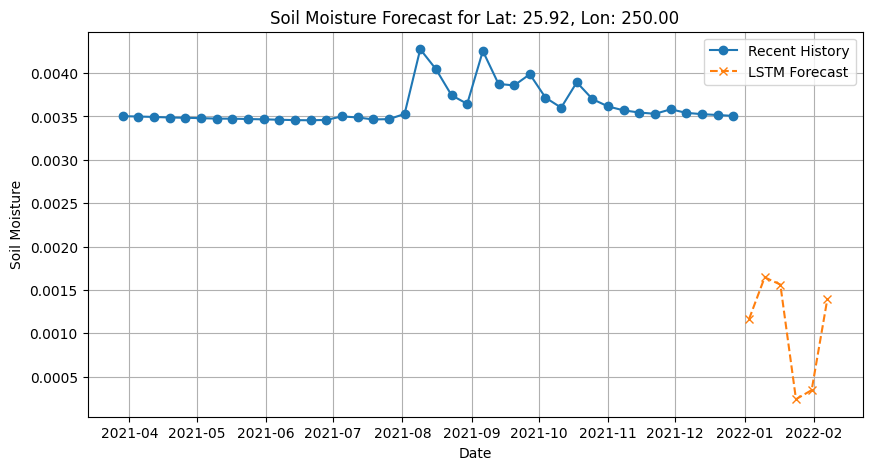

--- Diagnostics for Saved Model 2 ---
Lat: 25.92, Lon: 250.00


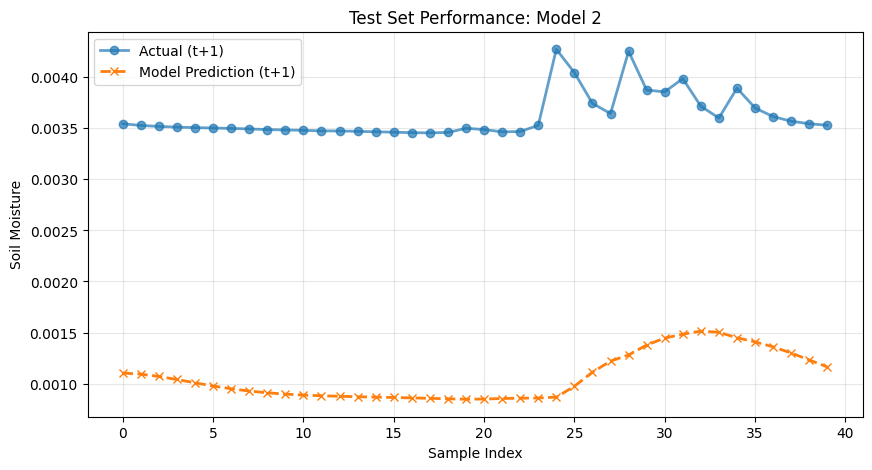


Data Summary for Location 2:
count    1200.000000
mean        0.026817
std         0.076794
min         0.003331
25%         0.003510
50%         0.003593
75%         0.003909
max         0.342541
Name: swvRZ, dtype: float64


In [ ]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import load_model

def plot_location_forecast(location_idx):
    file_path = f'lead_{look_back_window}/model_{location_idx}.h5'
    model = load_model(file_path)
    lat_val, lon_val = all_locations[location_idx]

    sm_series = ds_mondays['swvRZ'].sel(lat=lat_val, lon=lon_val, method='nearest').to_series()
    X, y, scaler = create_sequences(sm_series, look_back=look_back_window, horizon=forecast_horizon)

    last_sequence = X[-1:]
    prediction_scaled = model.predict(last_sequence, verbose=0)
    forecast = scaler.inverse_transform(prediction_scaled).flatten()

    hist_series = sm_series.tail(look_back_window)
    forecast_dates = pd.date_range(
        start=hist_series.index[-1] + pd.Timedelta(weeks=1),
        periods=len(forecast),
        freq='W-MON'
    )

    plt.figure(figsize=(10, 5))
    plt.plot(hist_series.index, hist_series.values, label='Recent History', marker='o')
    plt.plot(forecast_dates, forecast, label='LSTM Forecast', marker='x', linestyle='--')
    plt.title(f"Soil Moisture Forecast for Lat: {lat_val:.2f}, Lon: {lon_val:.2f}")
    plt.xlabel("Date")
    plt.ylabel("Soil Moisture")
    plt.legend()
    plt.grid(True)
    plt.show()

# Here you can view specific models based on the models number
loc_index = 2
rmse_v, mae_v, acc_v, l_at, l_on = evaluate_h5_model(loc_index)

print(f"Evaluation for {loc_index} (Lat: {l_at:.2f}, Lon: {l_on:.2f}):")
print(f"RMSE: {rmse_v:.4f}")
print(f"MAE:  {mae_v:.4f}")
print(f"ACC:  {acc_v:.4f}")

plot_location_forecast(loc_index)
diagnose_saved_model(loc_index)